In [59]:
import pandas as pd 
import matplotlib as plt
from sklearn.model_selection import train_test_split

We convert both of the datasets into dataframes, so that we can then work with them.

In [60]:
df_labels= pd.read_csv('GalaxyZoo1_DR_table2.csv', sep=";")
df_physics= pd.read_csv('Skyserver_SQL2_27_2018 6_51_39 PM.csv', sep=";")

print("LABEL COLUMNS: ", df_labels.columns)
print("PHYSICS COLUMNS: ", df_physics.columns)

LABEL COLUMNS:  Index(['OBJID', 'RA', 'DEC', 'NVOTE', 'P_EL', 'P_CW', 'P_ACW', 'P_EDGE',
       'P_DK', 'P_MG', 'P_CS', 'P_EL_DEBIASED', 'P_CS_DEBIASED', 'SPIRAL',
       'ELLIPTICAL', 'UNCERTAIN'],
      dtype='object')
PHYSICS COLUMNS:  Index(['objid', 'ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'run', 'rerun', 'camcol',
       'field', 'specobjid', 'class', 'redshift', 'plate', 'mjd', 'fiberid'],
      dtype='object')


At this point we know several things:
- OBJID don't match, so we have to merge both dataframes using another parameter: the location in space ('ra' and 'dec' columns)
- the name of columns must be both in upper or in lower letters
- types of both dataframes in 'ra' and 'dec' columns must match
- some columns are unnecessary
So, the next step must be to adapt and clear the dataframes.

In [61]:
#functions to convert types
def ra_sexadecimal_to_degrees(ra:str):
    h, m, s = map(float, ra.split(":"))
    return (h + m/60 + s/3600) * 15 # 1 hour -> 15 degrees

def dec_sexadecimal_to_degrees(dec:str):
    sign= -1 if dec[0]== "-" else 1
    dec= dec[1:] if dec[0]=="-" else dec
    d, m, s = map(float, dec.split(":"))
    return sign * (d + m/60 + s/3600)

#Rename the physis id column
df_physics.rename(columns= {"ra":"RA", "dec":'DEC'}, inplace= True)
print(df_physics.columns)

#convert types
df_labels['RA'] = df_labels['RA'].apply(ra_sexadecimal_to_degrees).round(4)
df_labels['DEC'] = df_labels['DEC'].apply(dec_sexadecimal_to_degrees).round(4)

df_physics['RA'] = df_physics['RA'].round(4)
df_physics['DEC'] = df_physics['DEC'].round(4)

#We delete the columns we are not interested in
df_physics = df_physics[['RA', 'DEC', 'u', 'g', 'r', 'i', 'z']]
df_labels = df_labels[['RA', 'DEC', 'P_EL', 'P_CS', 'SPIRAL', 'ELLIPTICAL', 'UNCERTAIN']]


Index(['objid', 'RA', 'DEC', 'u', 'g', 'r', 'i', 'z', 'run', 'rerun', 'camcol',
       'field', 'specobjid', 'class', 'redshift', 'plate', 'mjd', 'fiberid'],
      dtype='object')


Now that we have both of the dataframes clean, it's time to merge them

In [62]:
df_galaxies= pd.merge(df_physics, df_labels, on=['DEC', 'RA'])
print(len(df_galaxies))
print(df_galaxies)

3299
            RA      DEC         u         g         r         i         z  \
0     183.6802   0.1262  19.38298  18.19169  17.47428  17.08732  16.80125   
1     183.8644   0.0192  19.38322  17.88995  17.10537  16.66393  16.36955   
2     183.9735   0.0816  18.67249  17.71375  17.49362  17.28284  17.22644   
3     184.1896   0.0995  19.25667  17.54869  16.63578  16.14922  15.76639   
4     184.3809   0.1743  17.81661  16.86976  16.53884  16.19576  16.08668   
...        ...      ...       ...       ...       ...       ...       ...   
3294  131.0877  51.4059  18.50840  16.51681  15.54049  15.09710  14.77027   
3295  131.3989  51.5337  17.79613  16.02621  15.15955  14.71488  14.33840   
3296  131.3061  51.6713  18.27255  17.43849  17.07692  16.71661  16.69897   
3297  131.4772  51.7531  18.88287  17.91068  17.53152  17.36284  17.13988   
3298  131.6650  51.8053  19.27586  17.37829  16.30542  15.83548  15.50588   

        P_EL    P_CS  SPIRAL  ELLIPTICAL  UNCERTAIN  
0     303.00  60

We now get the proportions of the classes.

In [63]:
# get rid of the uncertain data
df_galaxies = df_galaxies[df_galaxies['UNCERTAIN'] == 0]

# get the proportions of classes
proportion_elliptical=0
proportion_spiral=0

for i in range (len(df_galaxies)):
    if df_galaxies.iloc[i]['ELLIPTICAL']==1:
        proportion_elliptical+=1
    else:
        proportion_spiral+=1

proportion_elliptical/=len(df_galaxies)
proportion_spiral/=len(df_galaxies)
print("PROPORTION OF ELLIPTICAL GALAXIES: ", proportion_elliptical)
print("PROPORTION OF SPIRAL GALAXIES: ", proportion_spiral)


PROPORTION OF ELLIPTICAL GALAXIES:  0.20054384772263767
PROPORTION OF SPIRAL GALAXIES:  0.7994561522773623


It's time of Feature Engineering. My next steps are :
* create a new column with *Color Indices*, since this is crucial to identify wether a galaxy is elliptical or spiral. This is given by the fact that ellipticals are younger and brighter, so they emit a lot of u and g and their color is blue; meanwhile spirals emit more r and i and the color is red, as they are older and colder.
* Decide which columns are "Features" (X) and which are "Labels" (Y)
* Convert the spiral and elliptical columns into one unique column
* Split the data into train and test sets

X ES:               u         g         r         i         z      u_g      g_r  \
660   19.11204  18.02115  17.41432  17.08203  16.87130  1.09089  0.60683   
1389  18.54162  17.24359  16.53755  16.16176  15.92815  1.29803  0.70604   
584   18.89477  17.09377  16.15349  15.73403  15.39552  1.80100  0.94028   
1053  19.19254  17.68097  16.89911  16.47630  16.18199  1.51157  0.78186   
1106  19.13091  17.72634  17.08864  16.71853  16.51603  1.40457  0.63770   
...        ...       ...       ...       ...       ...      ...      ...   
1095  19.09143  17.55236  16.79034  16.38590  16.11512  1.53907  0.76202   
1130  18.66635  17.32217  16.63370  16.22146  15.84027  1.34418  0.68847   
1294  19.45076  17.61312  16.61744  16.12243  15.73968  1.83764  0.99568   
860   19.30679  17.79842  16.96122  16.49667  16.16157  1.50837  0.83720   
1126  18.80408  17.22561  16.36152  15.87951  15.50822  1.57847  0.86409   

          r_i  
660   0.33229  
1389  0.37579  
584   0.41946  
1053  0.42281  


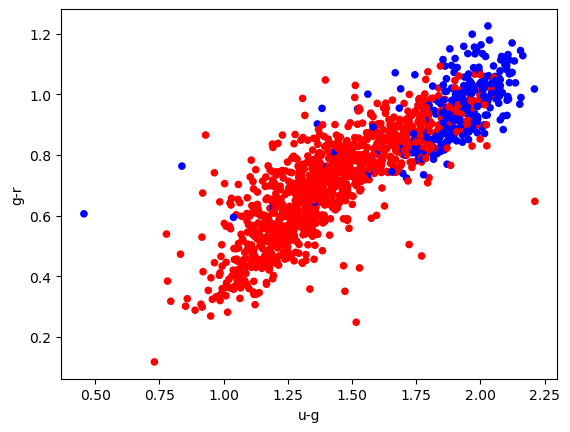

In [ ]:
#creating new columns 
df_galaxies['u_g']= df_galaxies['u']-df_galaxies['g']
df_galaxies['g_r']= df_galaxies['g']-df_galaxies['r']
df_galaxies['r_i']= df_galaxies['r']-df_galaxies['i']
print(df_galaxies)

#we clean the non-sense values
df_galaxies = df_galaxies[(df_galaxies['u_g'] < 5) & (df_galaxies['u_g'] > -1)]
df_galaxies = df_galaxies[(df_galaxies['g_r']<5) & (df_galaxies['g_r']>-1)]
df_galaxies = df_galaxies[(df_galaxies['r_i']<5) & (df_galaxies['r_i']>-1)]

#example plot
df_galaxies.plot(
    x='u_g', 
    y='g_r',
    kind='scatter', 
    xlabel="u-g", 
    ylabel="g-r", 
    color=df_galaxies['ELLIPTICAL'].map({1:'blue', 0:'red'})
)

#Divide features and labels
df_galaxies = df_galaxies.sample(frac=1, random_state=42).reset_index(drop=True)

x = df_galaxies[['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i']]
y = df_galaxies['ELLIPTICAL'] #this way we can know if it's spiral or elliptical with only one column

#Split the data into trains and test sets
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42)
